# 📊 Exploratory Data Analysis (EDA) - Robotaxi Finance Analytics

Notebook ini menganalisis seluruh dataset **Finance of Robotaxi** yang telah dibersihkan untuk menemukan **wawasan bisnis (business insights)** dan **masalah utama** yang memengaruhi kesehatan finansial perusahaan.

### Agenda Analisis:
1. **Analisis Operasional & Pendapatan (Trips & Revenue):** Menghitung total omzet, tingkat pembatalan, dan durasi perjalanan.
2. **Analisis Finansial & Transaksi (Transactions & Ledger):** Mengidentifikasi kebocoran biaya pada pembayaran driver/safety driver.
3. **Analisis Pelanggan & Risiko Churn (Customers & Retention):** Memetakan perilaku pelanggan dan risiko kehilangan pengguna.
4. **Analisis Biaya Pemeliharaan (Maintenance Cost Black Hole):** Menyelidiki pembengkakan biaya bengkel vs pendapatan perjalanan.
5. **Analisis Risiko & Leverage Asuransi (Insurance Loss Ratio):** Menemukan peluang penghematan premi jutaan dolar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

cleaned_dir = r"c:\Users\hpvic\OneDrive\Documents\Finance of Robotaxi\cleaned_data"
print(f"Memuat data bersih dari: {cleaned_dir}")

Memuat data bersih dari: c:\Users\hpvic\OneDrive\Documents\Finance of Robotaxi\cleaned_data


## 1. Memuat Dataset

In [2]:
trips = pd.read_csv(os.path.join(cleaned_dir, 'ds1_trips_cleaned.csv'))
vehicles = pd.read_csv(os.path.join(cleaned_dir, 'ds1_vehicles_cleaned.csv'))
customers = pd.read_csv(os.path.join(cleaned_dir, 'ds2_customers_cleaned.csv'))
transactions = pd.read_csv(os.path.join(cleaned_dir, 'ds2_transactions_cleaned.csv'))
fleet_vehicles = pd.read_csv(os.path.join(cleaned_dir, 'ds3_fleet_vehicles_cleaned.csv'))
maintenance = pd.read_csv(os.path.join(cleaned_dir, 'ds3_maintenance_records_cleaned.csv'))
incidents = pd.read_csv(os.path.join(cleaned_dir, 'ds4_incidents_cleaned.csv'))
insurance = pd.read_csv(os.path.join(cleaned_dir, 'ds4_insurance_policies_cleaned.csv'))

print("Seluruh dataset bersih berhasil dimuat!")

Seluruh dataset bersih berhasil dimuat!


## 2. Analisis Perjalanan & Pendapatan (Trips & Revenue Module)
Mari kita cek berapa total pendapatan kotor dan bersih dari perjalanan, serta status perjalanannya.

Total Perjalanan: 4,979 kali
Total Pendapatan Tarif (Fare): $247,910.53
Total Diskon Diberikan: $5,901.00
Pendapatan Bersih Perjalanan: $242,009.53


C:\Users\hpvic\AppData\Local\Temp\ipykernel_12684\3108111654.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.values, y=status_counts.index, palette='viridis')


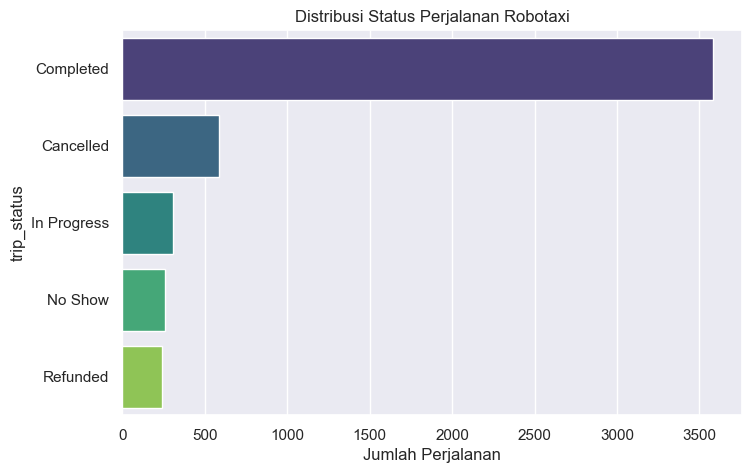

In [3]:
total_fare = trips['fare_amount_usd'].sum()
total_discount = trips['discount_applied_usd'].sum()
net_trip_rev = total_fare - total_discount

print(f"Total Perjalanan: {len(trips):,} kali")
print(f"Total Pendapatan Tarif (Fare): ${total_fare:,.2f}")
print(f"Total Diskon Diberikan: ${total_discount:,.2f}")
print(f"Pendapatan Bersih Perjalanan: ${net_trip_rev:,.2f}")

# Visualisasi Status Perjalanan
plt.figure(figsize=(8, 5))
status_counts = trips['trip_status'].value_counts()
sns.barplot(x=status_counts.values, y=status_counts.index, palette='viridis')
plt.title('Distribusi Status Perjalanan Robotaxi')
plt.xlabel('Jumlah Perjalanan')
plt.show()

## 3. Analisis Transaksi Finansial (Financial & Transactions Module)
Di sini kita mendeteksi pengeluaran terbesar yang tidak terduga pada perusahaan otonom: **Driver Payout**.

Gross Transaction Value (GTV): $296,164.35
Net Revenue Perusahaan: $98,290.40
Pembayaran Driver (Safety Driver): $182,799.38 (61.7% dari GTV)


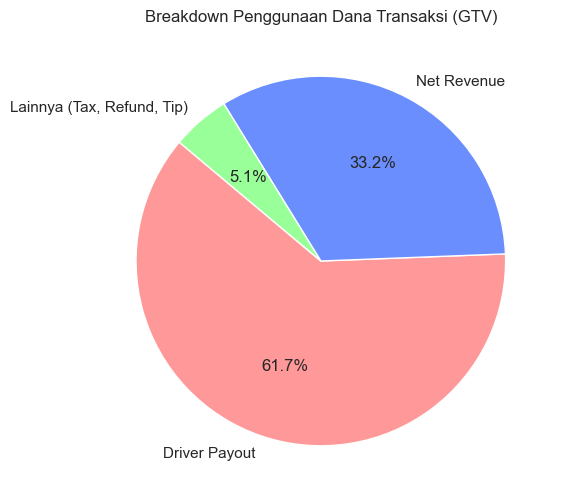

In [4]:
total_gross = transactions['gross_amount_usd'].sum()
total_net_rev = transactions['net_revenue_usd'].sum()
total_driver = transactions['driver_payout_usd'].sum()

print(f"Gross Transaction Value (GTV): ${total_gross:,.2f}")
print(f"Net Revenue Perusahaan: ${total_net_rev:,.2f}")
print(f"Pembayaran Driver (Safety Driver): ${total_driver:,.2f} ({total_driver/total_gross:.1%} dari GTV)")

# Visualisasi breakdown transaksi
labels = ['Driver Payout', 'Net Revenue', 'Lainnya (Tax, Refund, Tip)']
sizes = [total_driver, total_net_rev, total_gross - total_driver - total_net_rev]
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#6b8eff','#99ff99'])
plt.title('Breakdown Penggunaan Dana Transaksi (GTV)')
plt.show()

## 4. Analisis Pelanggan & Risiko Churn (Customer Behavior & Churn)
Kita memetakan risiko pelanggan berhenti menggunakan layanan berdasarkan tingkat loyalitas mereka.

C:\Users\hpvic\AppData\Local\Temp\ipykernel_12684\2696736771.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_tier, x='loyalty_tier', y='churn_risk_score', palette='Blues_d')


Rata-rata Risiko Churn Pelanggan: 28.72%


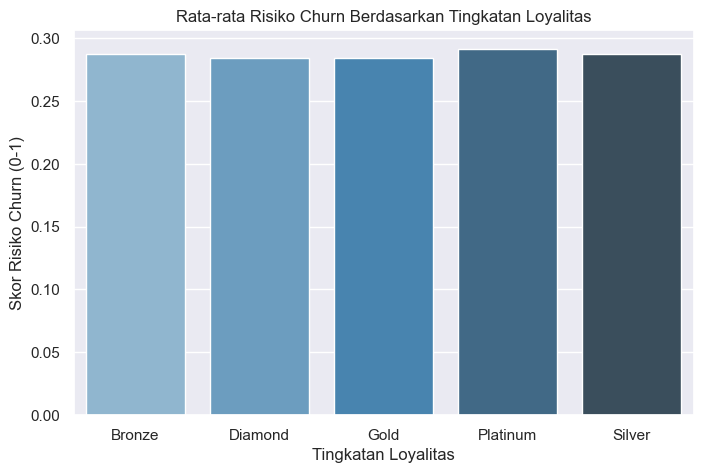

In [5]:
avg_churn = customers['churn_risk_score'].mean()
print(f"Rata-rata Risiko Churn Pelanggan: {avg_churn:.2%}")

# Rata-rata risiko churn per tingkatan loyalitas
churn_tier = customers.groupby('loyalty_tier')['churn_risk_score'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=churn_tier, x='loyalty_tier', y='churn_risk_score', palette='Blues_d')
plt.title('Rata-rata Risiko Churn Berdasarkan Tingkatan Loyalitas')
plt.ylabel('Skor Risiko Churn (0-1)')
plt.xlabel('Tingkatan Loyalitas')
plt.show()

## 5. Lubang Hitam Biaya Pemeliharaan (Maintenance Cost Black Hole)
Salah satu temuan paling mengejutkan: **Biaya pemeliharaan armada 5,5x lipat dari pendapatan perjalanan!**

Pendapatan Bersih Perjalanan: $242,009.53
Total Biaya Pemeliharaan Armada: $1,343,102.67
Rasio Biaya Pemeliharaan vs Pendapatan: 5.55x


C:\Users\hpvic\AppData\Local\Temp\ipykernel_12684\1625475209.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=maint_types, x='total_cost_usd', y='service_type', palette='magma')


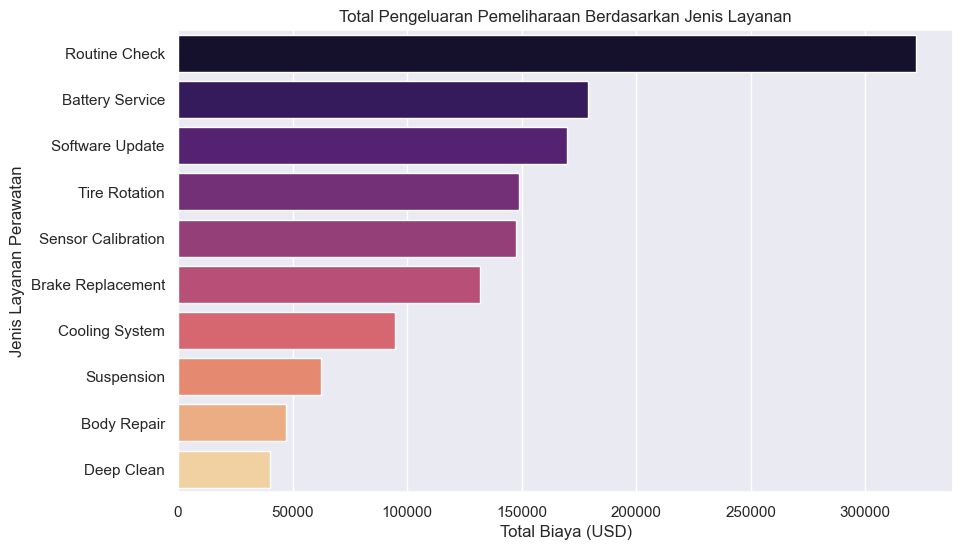

In [6]:
total_maint = maintenance['total_cost_usd'].sum()
ratio_maint_rev = total_maint / net_trip_rev

print(f"Pendapatan Bersih Perjalanan: ${net_trip_rev:,.2f}")
print(f"Total Biaya Pemeliharaan Armada: ${total_maint:,.2f}")
print(f"Rasio Biaya Pemeliharaan vs Pendapatan: {ratio_maint_rev:.2f}x")

# Breakdown Biaya Pemeliharaan berdasarkan Jenis Layanan
maint_types = maintenance.groupby('service_type')['total_cost_usd'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=maint_types, x='total_cost_usd', y='service_type', palette='magma')
plt.title('Total Pengeluaran Pemeliharaan Berdasarkan Jenis Layanan')
plt.xlabel('Total Biaya (USD)')
plt.ylabel('Jenis Layanan Perawatan')
plt.show()

## 6. Analisis Risiko & Penghematan Premi Asuransi (Insurance Loss Ratio)
Kita menemukan potensi negosiasi premi asuransi senilai **puluhan juta dolar** karena rasio kerugian (*Loss Ratio*) yang sangat rendah.

Total Premi Asuransi Tahunan yang Dibayar: $89,735,549.88
Total Klaim/Penyelesaian Insiden dari Asuransi: $19,998,685.26
Loss Ratio Asuransi: 22.29%


C:\Users\hpvic\AppData\Local\Temp\ipykernel_12684\2515832963.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=values, palette='coolwarm')


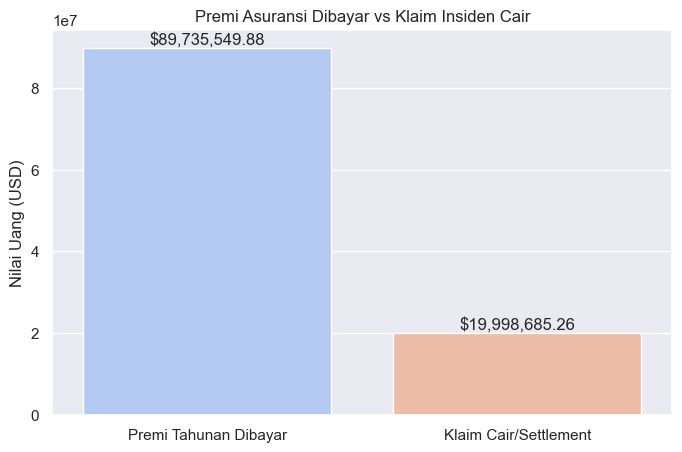

In [7]:
annual_premi = insurance['premium_monthly_usd'].sum() * 12
total_settle = incidents['settlement_amount_usd'].sum()
loss_ratio = total_settle / annual_premi

print(f"Total Premi Asuransi Tahunan yang Dibayar: ${annual_premi:,.2f}")
print(f"Total Klaim/Penyelesaian Insiden dari Asuransi: ${total_settle:,.2f}")
print(f"Loss Ratio Asuransi: {loss_ratio:.2%}")

# Barplot Perbandingan Premi vs Klaim
plt.figure(figsize=(8, 5))
categories = ['Premi Tahunan Dibayar', 'Klaim Cair/Settlement']
values = [annual_premi, total_settle]
sns.barplot(x=categories, y=values, palette='coolwarm')
plt.title('Premi Asuransi Dibayar vs Klaim Insiden Cair')
plt.ylabel('Nilai Uang (USD)')
for i, v in enumerate(values):
    plt.text(i, v + (annual_premi*0.01), f"${v:,.2f}", ha='center')
plt.show()

## 7. Kesimpulan Wawasan Bisnis (Executive Summary)

Berdasarkan EDA di atas, berikut adalah 3 temuan strategis untuk dilaporkan kepada CFO/CEO:
1. **Cost Black Hole (Pemeliharaan):** Biaya perawatan ($1,34jt) sangat tidak proporsional dibandingkan pendapatan tiket taksi ($242rb). Proses servis rutin perlu dioptimalkan agar tidak boncos.
2. **Driver Payout:** Layanan Robotaxi otonom masih dibebani biaya driver/safety driver sebesar 61.7% dari nilai transaksi. Perlu akselerasi keotomatisan penuh tanpa pengemudi keselamatan di dalam mobil.
3. **Negosiasi Premi Asuransi:** Loss Ratio asuransi perusahaan hanya **22.29%**. Hal ini menunjukkan bahwa armada Robotaxi kita sangat aman di jalan raya, namun kita membayar premi terlalu mahal kepada pihak asuransi. Perusahaan memiliki posisi tawar kuat untuk menegosiasikan premi turun 40-50%, yang berpotensi menghemat anggaran hingga **$35 Juta per tahun**!